# 0. **환경 세팅**

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception:
    pass  # Colab이 아니거나 이미 마운트되어 있으면 무시

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 프로젝트 변수 설정

%%bash
cat > vars.sh <<'EOF'
REPO_URL="https://github.com/z-bingo/kernel-prediction-networks-PyTorch.git"
REPO_DIR="kpn_repo"
CKPT_ID="1Xnpllr1dinAU7BIN21L3LkEP5AqMNWso"
CKPT_FILE="pretrained_kpn.pth.tar"
CONFIG_PATH="./kpn_specs/kpn_config.conf"
EVAL_SCRIPT="train_eval_syn.py"
ENV_NAME="kpnenv"
EOF

# 확인
source vars.sh
echo "REPO_URL=$REPO_URL
REPO_DIR=$REPO_DIR
CKPT_ID=$CKPT_ID
CKPT_FILE=$CKPT_FILE
CONFIG_PATH=$CONFIG_PATH
EVAL_SCRIPT=$EVAL_SCRIPT
ENV_NAME=$ENV_NAME"


REPO_URL=https://github.com/z-bingo/kernel-prediction-networks-PyTorch.git
REPO_DIR=kpn_repo
CKPT_ID=1Xnpllr1dinAU7BIN21L3LkEP5AqMNWso
CKPT_FILE=pretrained_kpn.pth.tar
CONFIG_PATH=./kpn_specs/kpn_config.conf
EVAL_SCRIPT=train_eval_syn.py
ENV_NAME=kpnenv


In [ ]:
# micromamba 설치

%%bash
wget -qO- https://micro.mamba.pm/api/micromamba/linux-64/latest | tar -xvj bin/micromamba


bin/micromamba


In [ ]:
# 환경 생성

%%bash
source vars.sh
eval "$(./bin/micromamba shell hook -s bash)"
micromamba create -y -n "$ENV_NAME" python=3.9
micromamba run -n "$ENV_NAME" python -V




Transaction

  Prefix: /root/.local/share/mamba/envs/kpnenv

  Updating specs:

   - python=3.9


  Package                Version  Build                 Channel          Size
───────────────────────────────────────────────────────────────────────────────
  Install:
───────────────────────────────────────────────────────────────────────────────

  + _libgcc_mutex            0.1  conda_forge           conda-forge       3kB
  + _openmp_mutex            4.5  2_gnu                 conda-forge      24kB
  + bzip2                  1.0.8  hda65f42_8            conda-forge     260kB
  + ca-certificates   2025.11.12  hbd8a1cb_0            conda-forge     152kB
  + icu                     78.1  h33c6efd_0            conda-forge      13MB
  + ld_impl_linux-64        2.45  default_hbd61a6d_104  conda-forge     726kB
  + libexpat               2.7.3  hecca717_0            conda-forge      77kB
  + libffi                 3.5.2  h9ec8514_0            conda-forge      58kB
  + libgcc                

In [ ]:
#깃헙 레포 연결

%%bash
source vars.sh
rm -rf "$REPO_DIR"
git clone --depth 1 "$REPO_URL" "$REPO_DIR"
cd "$REPO_DIR"
git fetch --tags
git rev-parse --short HEAD


66b7dc7


Cloning into 'kpn_repo'...


In [ ]:
#conda-forge로 “핵심 과학 스택”만 설치 (opencv/protobuf 제외)

%%bash
source vars.sh
eval "$(./bin/micromamba shell hook -s bash)"

# 과학 스택(NumPy 1.23.5 & skimage 0.19.3)만 conda-forge 바이너리로
micromamba install -y -n "$ENV_NAME" -c conda-forge \
  "python=3.9" "pip<24" "setuptools<81" "wheel" \
  "numpy=1.23.5" "scikit-image=0.19.3" "pillow=9.5.0" \
  "imageio=2.31.1" "matplotlib=3.7.*" "tqdm"

# 버전 스냅샷(여기서 numpy 1.23.5, skimage 0.19.3가 보여야 정상)
micromamba run -n "$ENV_NAME" python - <<'PY'
import numpy as np, skimage, PIL
print("numpy:", np.__version__)
print("skimage:", skimage.__version__)
import PIL as _P; print("Pillow:", _P.__version__)
PY


conda-forge/linux-64                                        Using cache
conda-forge/noarch                                          Using cache


Transaction

  Prefix: /root/.local/share/mamba/envs/kpnenv

  Updating specs:

   - python=3.9
   - pip<24
   - setuptools<81
   - wheel
   - numpy=1.23.5
   - scikit-image=0.19.3
   - pillow=9.5.0
   - imageio=2.31.1
   - matplotlib=3.7
   - tqdm


  Package                           Version  Build                Channel           Size
──────────────────────────────────────────────────────────────────────────────────────────
  Install:
──────────────────────────────────────────────────────────────────────────────────────────

  + alsa-lib                       1.2.15.1  hb03c661_0           conda-forge      585kB
  + aom                               3.9.1  hac33072_0           conda-forge        3MB
  + attr                              2.5.2  h39aace5_0           conda-forge       68kB
  + blosc                            1.21.5  h0f2a231

In [ ]:
# PyTorch CPU + torchvision만 먼저

%%bash
source vars.sh
eval "$(./bin/micromamba shell hook -s bash)"

cat > /tmp/constraints.txt <<'EOF'
numpy<2
EOF
export PIP_PREFER_BINARY=1

# 토치/토치비전(구세대 CPU 빌드)
micromamba run -n "$ENV_NAME" pip install -q -c /tmp/constraints.txt \
  torch==1.10.2+cpu torchvision==0.11.3+cpu \
  -f https://download.pytorch.org/whl/torch_stable.html

# 확인
micromamba run -n "$ENV_NAME" python - <<'PY'
import torch
print("torch:", torch.__version__, "cuda_available:", torch.cuda.is_available())
PY


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.3/199.3 MB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 108.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 3.0 MB/s eta 0:00:00
torch: 1.10.2+cpu cuda_available: False


/root/.local/share/mamba/envs/kpnenv/lib/python3.9/site-packages/torch/torch_version.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging  # type: ignore[attr-defined]


In [ ]:
%%bash
set -e
cd /content
curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest | tar -xvj bin/micromamba
install -Dm755 bin/micromamba /usr/local/bin/micromamba
micromamba --version


bin/micromamba
2.4.0


In [ ]:
%%bash
# 목적: CPU 전용 torch를 GPU 빌드로 교체
set -e
eval "$(micromamba shell hook -s bash || true)"

# CPU 버전 제거
micromamba run -n kpnenv pip uninstall -y torch torchvision || true

# GPU 버전 설치 (Colab GPU에 맞는 CUDA 12.1 빌드)
micromamba run -n kpnenv pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

# 설치 확인
micromamba run -n kpnenv python - <<'PY'
import torch
print("✅ torch:", torch.__version__)
print("✅ CUDA available:", torch.cuda.is_available())
print("✅ CUDA device count:", torch.cuda.device_count())
PY


Found existing installation: torch 1.10.2+cpu
Uninstalling torch-1.10.2+cpu:
  Successfully uninstalled torch-1.10.2+cpu
Found existing installation: torchvision 0.11.3+cpu
Uninstalling torchvision-0.11.3+cpu:
  Successfully uninstalled torchvision-0.11.3+cpu
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 120.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 104.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 62.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 135.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 22.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# 나머지 패키지(문제 의심 validate는 제외)

%%bash
source vars.sh
eval "$(./bin/micromamba shell hook -s bash)"

cat > /tmp/constraints.txt <<'EOF'
numpy<2
EOF
export PIP_PREFER_BINARY=1

micromamba run -n "$ENV_NAME" pip install -q -c /tmp/constraints.txt \
  opencv-python==4.7.0.72 protobuf==3.20.3 \
  configobj==5.0.8 imageio==2.31.1 tensorboardX==2.6

# 확인
micromamba run -n "$ENV_NAME" python - <<'PY'
import cv2, google.protobuf, configobj, imageio, tensorboardX
print("opencv:", cv2.__version__)
print("protobuf:", google.protobuf.__version__)
print("configobj:", configobj.__version__)
print("imageio:", imageio.__version__)
print("tensorboardX:", tensorboardX.__version__)
PY


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.8/61.8 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.5/114.5 kB 10.9 MB/s eta 0:00:00
opencv: 4.7.0
protobuf: 3.20.3
configobj: 5.0.8
imageio: 2.31.1
tensorboardX: 2.6


In [ ]:
%%bash
# 목적: environment.yml 저장 후 kpnenv(없으면 생성/있으면 업데이트) A단게

set -e

# micromamba 초기화 & ENV_NAME 기본값
source vars.sh 2>/dev/null || true
: "${ENV_NAME:=kpnenv}"
eval "$(./bin/micromamba shell hook -s bash)"

# 기본 스택을 environment.yml로 고정
cat > environment.yml <<'YML'
name: kpnenv
channels:
  - conda-forge
dependencies:
  - python=3.9
  - pip<24
  - setuptools<81
  - wheel
  - numpy=1.23.5
  - scikit-image=0.19.3
  - pillow=9.5.0
  - imageio=2.31.1
  - matplotlib=3.7
  - tqdm
  - configobj=5.0.8
YML

# kpnenv 유무에 따라 create 또는 update
if ./bin/micromamba env list | grep -qE "^[[:space:]]*$ENV_NAME[[:space:]]"; then
  echo "➡️ Updating existing env: $ENV_NAME"
  ./bin/micromamba env update -n "$ENV_NAME" -f environment.yml
else
  echo "➡️ Creating env: $ENV_NAME"
  ./bin/micromamba env create -n "$ENV_NAME" -f environment.yml
fi

# 확인 출력
./bin/micromamba run -n "$ENV_NAME" python -c "import sys; print('Python', sys.version.split()[0])"


➡️ Updating existing env: kpnenv
conda-forge/linux-64                                        Using cache
conda-forge/noarch                                          Using cache

Transaction

  Prefix: /root/.local/share/mamba/envs/kpnenv

  Updating specs:

   - python=3.9
   - pip<24
   - setuptools<81
   - wheel
   - numpy=1.23.5
   - scikit-image=0.19.3
   - pillow=9.5.0
   - imageio=2.31.1
   - matplotlib=3.7
   - tqdm
   - configobj=5.0.8


  Package      Version  Build         Channel         Size
────────────────────────────────────────────────────────────
  Install:
────────────────────────────────────────────────────────────

  + configobj    5.0.8  pyhd8ed1ab_0  conda-forge     37kB

  Summary:

  Install: 1 packages

  Total download: 37kB

────────────────────────────────────────────────────────────


Confirm changes: [Y/n] 
Transaction starting
Linking configobj-5.0.8-pyhd8ed1ab_0

Transaction finished



warning  libmamba [configobj-5.0.8-pyhd8ed1ab_0] The following files were already present in the environment:
    - lib/python3.9/site-packages/configobj-5.0.8.dist-info/INSTALLER
    - lib/python3.9/site-packages/configobj-5.0.8.dist-info/LICENSE
    - lib/python3.9/site-packages/configobj-5.0.8.dist-info/METADATA
    - lib/python3.9/site-packages/configobj-5.0.8.dist-info/RECORD
    - lib/python3.9/site-packages/configobj-5.0.8.dist-info/REQUESTED
    - lib/python3.9/site-packages/configobj-5.0.8.dist-info/WHEEL
    - lib/python3.9/site-packages/configobj-5.0.8.dist-info/top_level.txt
    - lib/python3.9/site-packages/configobj/__init__.py
    - lib/python3.9/site-packages/configobj/_version.py
    - lib/python3.9/site-packages/configobj/validate.py
    - lib/python3.9/site-packages/validate/__init__.py


# **1. KPN 준비**

In [ ]:
%%bash
set -e

echo "📦 Installing micromamba..."
curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest | tar -xvj bin/micromamba
sudo mv bin/micromamba /usr/local/bin/micromamba
chmod +x /usr/local/bin/micromamba

echo "✅ micromamba installed at:"
which micromamba
micromamba --version


📦 Installing micromamba...
bin/micromamba
✅ micromamba installed at:
/usr/local/bin/micromamba
2.4.0


In [ ]:
%%bash
CONF_FILE="/content/kpn_repo/kpn_specs/kpn_config.conf"

# architecture 섹션에 필요한 키 추가 (없을 경우에만)
if ! grep -q "spatial_att" "$CONF_FILE"; then
  echo '    spatial_att = false' >> "$CONF_FILE"
fi

if ! grep -q "channel_att" "$CONF_FILE"; then
  echo '    channel_att = false' >> "$CONF_FILE"
fi

echo "✅ config 보강 완료. 현재 [architecture] 섹션:"
grep -A4 "\[architecture\]" "$CONF_FILE"



✅ config 보강 완료. 현재 [architecture] 섹션:
[architecture]
    arch = "kpn"

    kernel_size = 5
    sep_conv = False


In [ ]:
%%bash
# 🎯 목적: torchsummary 설치 + 정상 여부 확인
set -e
eval "$(/usr/local/bin/micromamba shell hook -s bash || true)"

echo "📦 Installing torchsummary..."
/usr/local/bin/micromamba run -n kpnenv pip install -q torchsummary

# 설치 확인 (버전 속성 없이 존재 여부만 확인)
echo "🔍 Checking import..."
/usr/local/bin/micromamba run -n kpnenv python - <<'PY'
import importlib.util
spec = importlib.util.find_spec("torchsummary")
print("✅ torchsummary importable:", spec is not None)
from torchsummary import summary
print("✅ torchsummary functional (summary callable):", callable(summary))
PY


📦 Installing torchsummary...
🔍 Checking import...
✅ torchsummary importable: True
✅ torchsummary functional (summary callable): True


In [ ]:
import torch

src_path = "/content/drive/MyDrive/kpn_models/model_best.pth.tar"
dst_path = "/content/drive/MyDrive/kpn_models/model_best_clean.pth.tar"

print(f"🧩 Loading checkpoint safely: {src_path}")
ckpt = torch.load(src_path, map_location="cpu", weights_only=False)

if "state_dict" in ckpt:
    state_dict = ckpt["state_dict"]
else:
    state_dict = ckpt

# "module." 접두어 제거
new_state_dict = {}
for k, v in state_dict.items():
    new_key = k.replace("module.", "") if k.startswith("module.") else k
    new_state_dict[new_key] = v

ckpt["state_dict"] = new_state_dict

torch.save(ckpt, dst_path)
print(f"✅ Cleaned checkpoint saved: {dst_path}")


🧩 Loading checkpoint safely: /content/drive/MyDrive/kpn_models/model_best.pth.tar
✅ Cleaned checkpoint saved: /content/drive/MyDrive/kpn_models/model_best_clean.pth.tar


# **2. input (noisy & gt) 이미지 경로 관련**

In [ ]:
%%bash
# 🎯 목적: eval_images → KPN 호환 데이터 구조로 변환
set -e
SRC="/content/kpn_repo/eval_images"
DST="/content/kpn_repo/dataset/eval_ready"

rm -rf "$DST"
mkdir -p "$DST/noisy"
mkdir -p "$DST/gt"

# noisy와 gt 파일만 복사
find "$SRC" -type f -name "*noisy*.png" -exec cp {} "$DST/noisy/" \;
find "$SRC" -type f -name "*gt*.png" -exec cp {} "$DST/gt/" \;

echo "✅ Dataset prepared under $DST"
echo "Noisy samples:" $(ls "$DST/noisy" | wc -l)
echo "GT samples:" $(ls "$DST/gt" | wc -l)


✅ Dataset prepared under /content/kpn_repo/dataset/eval_ready
Noisy samples: 108
GT samples: 99


In [ ]:
%%bash
# png -> bmp

SRC="/content/kpn_repo/dataset/eval_ready"
find "$SRC/noisy" -type f -name "*.png" | while read f; do
  cp "$f" "${f%.png}.bmp"
done
find "$SRC/gt" -type f -name "*.png" | while read f; do
  cp "$f" "${f%.png}.bmp"
done
echo "✅ Converted PNGs to BMP copies."


✅ Converted PNGs to BMP copies.


In [ ]:
%%bash
# 🎯 목적: noisy 파일명을 gt와 일관되게 정리 (##_noisy.bmp 형식)
set -e
BASE="/content/kpn_repo/dataset/eval_ready/noisy"

cd "$BASE"
echo "🔍 Before rename:"
ls | head

# noisy 파일 이름 패턴: 10_noisy_34.50dB_0.8800.bmp → 10_noisy.bmp
for f in *_noisy_*.bmp; do
  newname=$(echo "$f" | sed -E 's/_noisy_.*/_noisy.bmp/')
  mv -f "$f" "$newname"
done

# png도 동일하게 처리 (혹시 있을 경우)
for f in *_noisy_*.png; do
  newname=$(echo "$f" | sed -E 's/_noisy_.*/_noisy.png/')
  mv -f "$f" "$newname"
done

echo "✅ After rename:"
ls | head


🔍 Before rename:
10_noisy_34.50dB_0.8800.bmp
10_noisy_34.50dB_0.8800.png
11_noisy_34.61dB_0.8585.bmp
11_noisy_34.61dB_0.8585.png
12_noisy_34.56dB_0.8722.bmp
12_noisy_34.56dB_0.8722.png
13_noisy_34.48dB_0.8867.bmp
13_noisy_34.48dB_0.8867.png
14_noisy_34.69dB_0.8965.bmp
14_noisy_34.69dB_0.8965.png
✅ After rename:
10_noisy.bmp
10_noisy.png
11_noisy.bmp
11_noisy.png
12_noisy.bmp
12_noisy.png
13_noisy.bmp
13_noisy.png
14_noisy.bmp
14_noisy.png


In [ ]:
%%bash
# 🎯 목적: noisy/gt 폴더 내에서 png 제거, bmp만 유지
rm -f /content/kpn_repo/dataset/eval_ready/noisy/*.png
rm -f /content/kpn_repo/dataset/eval_ready/gt/*.png

echo "✅ Removed all .png files, kept only .bmp versions."


✅ Removed all .png files, kept only .bmp versions.


In [ ]:
! mkdir -p /content/kpn_repo/kpn_specs/dataset_specs


In [ ]:
%%bash
set -e
TARGET_DIR="/content/kpn_repo/dataset/Adobe5K"
echo "📂 Target directory: $TARGET_DIR"

micromamba run -n kpnenv python - <<'PY'
import os

target_dir = "/content/kpn_repo/dataset/Adobe5K"
deleted = 0

for root, _, files in os.walk(target_dir):
    for f in files:
        if f.lower().endswith(".png"):
            path = os.path.join(root, f)
            try:
                os.remove(path)
                print(f"🗑️ Deleted: {path}")
                deleted += 1
            except Exception as e:
                print(f"⚠️ Failed to delete {path}: {e}")

print(f"✅ Done! Total deleted PNG files: {deleted}")
PY

echo "📊 Checking remaining PNG files..."
find "$TARGET_DIR" -type f -name "*.png" | wc -l


📂 Target directory: /content/kpn_repo/dataset/Adobe5K
✅ Done! Total deleted PNG files: 0
📊 Checking remaining PNG files...
0


find: ‘/content/kpn_repo/dataset/Adobe5K’: No such file or directory


In [ ]:
%%bash
mkdir -p /content/kpn_repo/dataset/Adobe5K
cp -r /content/kpn_repo/dataset/eval_ready/* /content/kpn_repo/dataset/Adobe5K/
echo "✅ Copied eval_ready → Adobe5K"
ls -R /content/kpn_repo/dataset/Adobe5K | head


✅ Copied eval_ready → Adobe5K
/content/kpn_repo/dataset/Adobe5K:
gt
noisy

/content/kpn_repo/dataset/Adobe5K/gt:
10_gt.bmp
11_gt.bmp
12_gt.bmp
13_gt.bmp
14_gt.bmp


In [ ]:
%%bash
set -e
BASE_DIR="/content/kpn_repo/dataset/Adobe5K"

echo "📂 Target base directory: $BASE_DIR"

# 1️⃣ gt 폴더 안의 파일을 이동 (이름 변경 없이)
if [ -d "$BASE_DIR/gt" ]; then
  echo "🚚 Moving GT files..."
  find "$BASE_DIR/gt" -type f -name "*.bmp" | while read -r f; do
    mv "$f" "$BASE_DIR/"
  done
else
  echo "⚠️ GT folder not found!"
fi

# 2️⃣ noisy, gt 폴더 삭제
echo "🧹 Cleaning up subfolders..."
rm -rf "$BASE_DIR/gt" "$BASE_DIR/noisy"

# 3️⃣ 결과 확인
echo "✅ Final structure:"
ls -lh "$BASE_DIR" | head


📂 Target base directory: /content/kpn_repo/dataset/Adobe5K
🚚 Moving GT files...
🧹 Cleaning up subfolders...
✅ Final structure:
total 13M
-rw-r--r-- 1 root root 116K Dec 22 03:17 10_gt.bmp
-rw-r--r-- 1 root root 104K Dec 22 03:17 11_gt.bmp
-rw-r--r-- 1 root root 102K Dec 22 03:17 12_gt.bmp
-rw-r--r-- 1 root root 118K Dec 22 03:17 13_gt.bmp
-rw-r--r-- 1 root root 148K Dec 22 03:17 14_gt.bmp
-rw-r--r-- 1 root root 146K Dec 22 03:17 15_gt.bmp
-rw-r--r-- 1 root root 132K Dec 22 03:17 16_gt.bmp
-rw-r--r-- 1 root root 143K Dec 22 03:17 17_gt.bmp
-rw-r--r-- 1 root root 111K Dec 22 03:17 18_gt.bmp


# 기타 처리

In [ ]:
%%bash
cd /content/kpn_repo
mkdir -p models/kpn/eval_images models/kpn/checkpoint
ls -lh models/kpn/checkpoint


total 4.0K
-rw-r--r-- 1 root root 237 Dec 22 03:14 README.md


In [ ]:
%%bash
set -e

CHK_DIR="/content/drive/MyDrive/kpn_models"
echo "🔍 Checkpoint dir: $CHK_DIR"
ls -lh "$CHK_DIR" || true

python - <<'PY'
import os, shutil, torch

chk_dir = "/content/drive/MyDrive/kpn_models"

# 우선순위: 이미 'clean'이라고 표시된 것들 > 일반 best > 특정 스텝
candidates = [
    "model_best_clean_FIXED.pth.tar",
    "model_best_clean.pth.tar",
    "model_best.pth.tar",
    "000001.pth.tar",
]

candidates = [os.path.join(chk_dir, f) for f in candidates if os.path.isfile(os.path.join(chk_dir, f))]
if not candidates:
    raise SystemExit("❌ No checkpoint files found in " + chk_dir)

def is_clean(p):
    ckpt = torch.load(p, map_location="cpu")
    sd = ckpt.get("state_dict", {})
    # state_dict가 없으면 일단 깨끗하다고 간주
    if not sd:
        return True
    return not any(k.startswith("module.") for k in sd.keys())

picked = None
for p in candidates:
    try:
        if is_clean(p):
            picked = p
            print(f"✅ Clean checkpoint found: {os.path.basename(p)}")
            break
    except Exception as e:
        print(f"⚠️ Skip {os.path.basename(p)} (failed to read): {e}")

dst = os.path.join(chk_dir, "model_best.pth.tar")

if picked is None:
    # 첫 후보를 깨끗하게 만들어 저장
    src = candidates[0]
    print(f"🧼 Cleaning (remove 'module.'): {os.path.basename(src)}")
    ckpt = torch.load(src, map_location="cpu")
    sd = ckpt.get("state_dict", {})
    new_sd = { (k[7:] if k.startswith("module.") else k): v for k, v in sd.items() }
    ckpt["state_dict"] = new_sd
    fixed = os.path.join(chk_dir, "model_best_clean_AUTOFIXED.pth.tar")
    torch.save(ckpt, fixed)
    picked = fixed
    print(f"✅ Saved cleaned checkpoint: {os.path.basename(fixed)}")

# 최종적으로 model_best.pth.tar 로 준비
if os.path.abspath(picked) != os.path.abspath(dst):
    shutil.copy2(picked, dst)
print(f"🎯 USING: {dst}")
PY

echo "📁 Final contents:"
ls -lh "$CHK_DIR"


🔍 Checkpoint dir: /content/drive/MyDrive/kpn_models
lrw------- 1 root root 0 Oct 14 16:35 /content/drive/MyDrive/kpn_models -> /content/drive/.shortcut-targets-by-id/1MTp5V5D_iBxasf--rhR1_-UrrDrE_PkS/models
✅ Clean checkpoint found: model_best_clean_FIXED.pth.tar
🎯 USING: /content/drive/MyDrive/kpn_models/model_best.pth.tar
📁 Final contents:
lrw------- 1 root root 0 Oct 14 16:35 /content/drive/MyDrive/kpn_models -> /content/drive/.shortcut-targets-by-id/1MTp5V5D_iBxasf--rhR1_-UrrDrE_PkS/models


# **gt 1장 -> noisy N장**

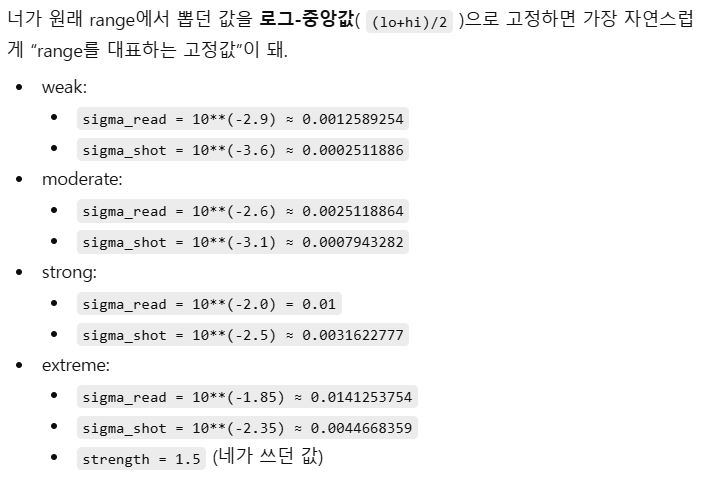

✅ Done
   Noisy frames ->  /content/drive/MyDrive/kpn_custom_noisy1_extreme
   Visuals/GT  ->  /content/drive/MyDrive/kpn_custom_noisy1_extreme_viz
   Trajectory  ->  [(0.0, 0.0), (0.3929383711957233, -0.42772133009924107), (-0.5462970928715938, 0.10262953816578246), (0.43893793957112615, -0.15378707975107808), (0.961528396769231, 0.3696594771697266), (-0.03813619703127813, -0.21576496361169895), (-0.3136439676982612, 0.45809941476808325), (-0.12285551064075118, -0.8806442067808633), (-0.20391148933913716, 0.4759908114640714), (-0.635016539093, -0.6490964877050149), (0.06310274768367674, 0.06365517419373212), (0.2688019171026421, 0.6988635881555791), (0.4489106497212705, 0.22204702135516574), (0.4448867651404431, -0.3540821722936436), (-0.2764226887553718, -0.5434735382420888), (-0.41257190722234127, 0.2619522477089755), (-0.8157901201098496, -0.13259765464094353), (-0.1382744733407124, -0.01262980469938757), (-0.14833941940834405, -0.37547755405506944), (-0.14729738607438358, 0.786778

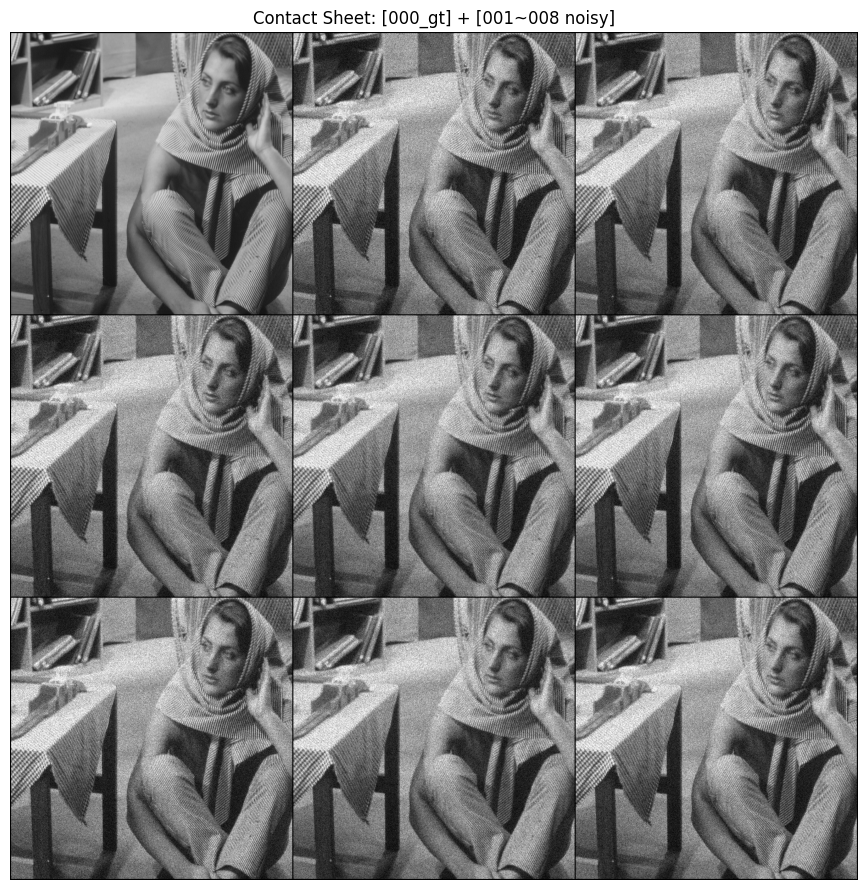

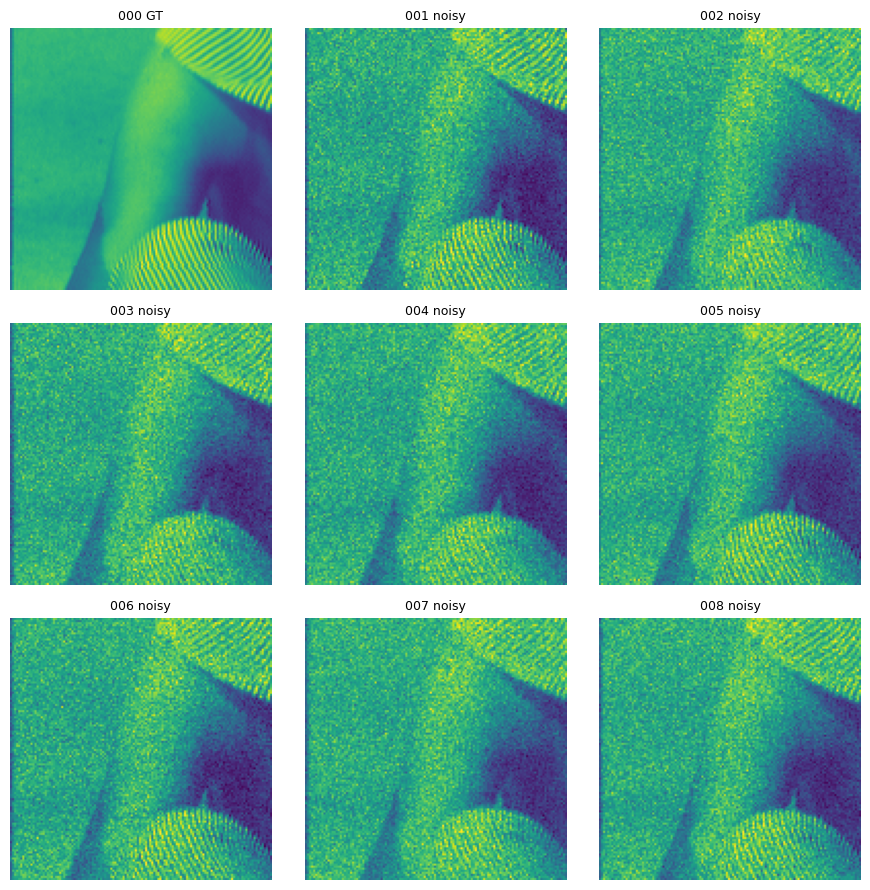

/tmp/ipython-input-3925707889.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


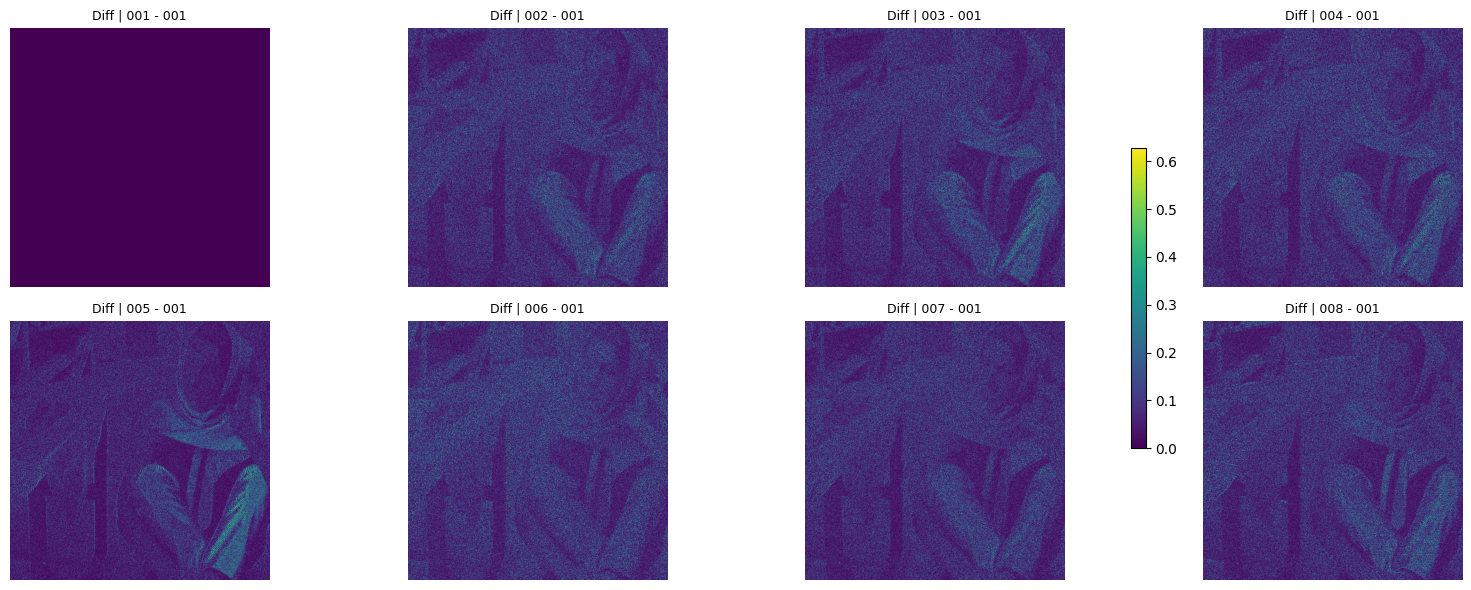

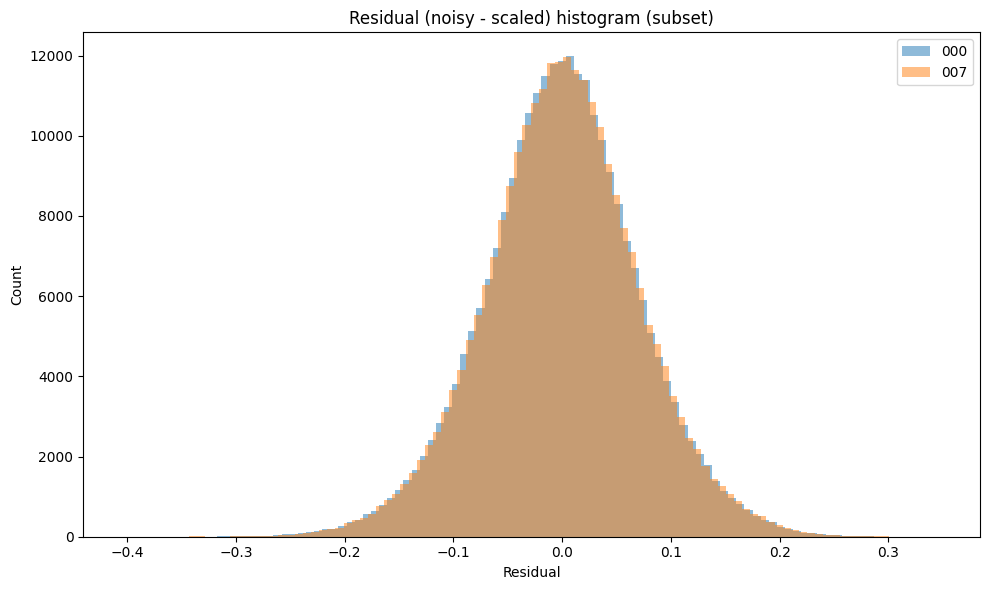

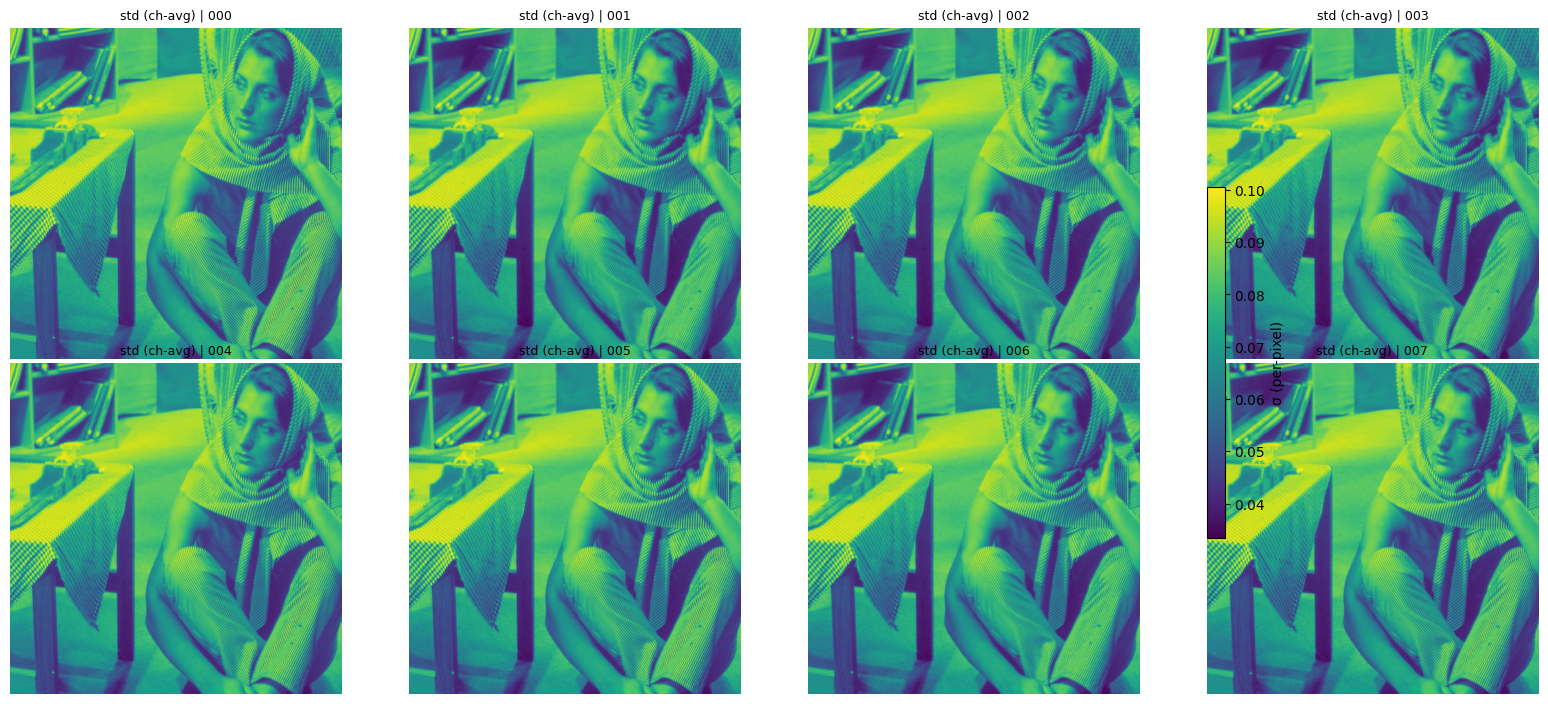

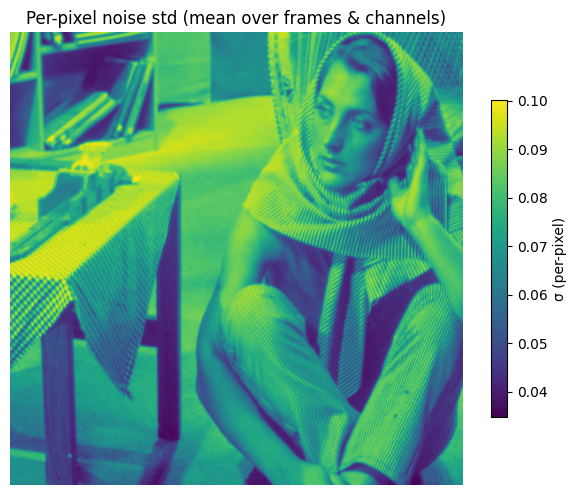

🖼️ Saved NOISY to: /content/drive/MyDrive/kpn_custom_noisy1_extreme
📁 Saved Visuals & GT to: /content/drive/MyDrive/kpn_custom_noisy1_extreme_viz


In [ ]:
# === Make noisy frames (with motion) from a single GT image, no resizing ===
from pathlib import Path
import torch, numpy as np
from PIL import Image
import torchvision.transforms.functional as TF
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
import math

# ---- user inputs ----
GT_PATH = "/content/drive/MyDrive/gt_new/1.gif"   # GT 이미지 경로
NOISY_DIR = Path("/content/drive/MyDrive/kpn_custom_noisy1_extreme")  # noisy만 저장
BURST_LEN = 40                                         # 생성할 noisy 프레임 수 (>=1)
MAX_SHIFT = 1                                          # 프레임 간 최대 이동(px)
SEED = 123                                             # 재현성 원하면 고정

# ---- setup ----
NOISY_DIR.mkdir(parents=True, exist_ok=True)
VIZ_DIR = NOISY_DIR.with_name(NOISY_DIR.name + "_viz")  # 시각화/부가물 저장 폴더
VIZ_DIR.mkdir(parents=True, exist_ok=True)

if SEED is not None:
    np.random.seed(SEED)
    torch.manual_seed(SEED)

# ---- load GT, to [C,H,W] in [0,1] ----
gt_img = Image.open(GT_PATH).convert("L")
gt = TF.to_tensor(gt_img)  # [3,H,W], float32, [0,1]
C, H, W = gt.shape

# ---- util: grid 행/열 자동 계산 (최대 열수 고정 옵션) ----
def auto_rows_cols(n_items, max_cols=3):
    cols = min(max_cols, max(1, n_items))
    rows = math.ceil(n_items / cols)
    return rows, cols

# ---- build motion (subpixel affine) without resizing ----
def shift_image(img, dx, dy):
    # img: [1,C,H,W], dx/dy in pixels (positive: right/down)
    theta = torch.tensor([[[1, 0, dx * 2 / (W - 1)],
                           [0, 1, dy * 2 / (H - 1)]]],
                         dtype=img.dtype, device=img.device)
    grid = F.affine_grid(theta, img.size(), align_corners=True)
    return F.grid_sample(img, grid, mode="bilinear",
                         padding_mode="border", align_corners=True)

# ---- motion trajectory (non-cumulative jitter) ----
burst = []
burst.append(gt.unsqueeze(0))  # [1,3,H,W] (frame 0: unshifted)

steps = [(0.0, 0.0)]  # for logging

for i in range(1, BURST_LEN):
    dx = float(np.random.uniform(-MAX_SHIFT, MAX_SHIFT))
    dy = float(np.random.uniform(-MAX_SHIFT, MAX_SHIFT))
    shifted = shift_image(gt.unsqueeze(0), dx, dy)  # 항상 원본 기준(비누적)
    burst.append(shifted)
    steps.append((dx, dy))

burst = torch.cat(burst, dim=0)  # [B,3,H,W], B=BURST_LEN

# ---- apply read/shot noise (white_level = 1 고정) ----
white_level = torch.tensor(1.0, dtype=burst.dtype, device=burst.device)

preset = "extreme"  # weak | moderate | strong | extreme

# 필요하면 상한 클램프(하이라이트 shot 과증가 보호). 0이면 비활성
std_max = 0.0  # 예: 0.08

# ---- 고정 파라미터 테이블 ----
FIXED = {
    "weak": {
        "sigma_read": 0.0012589254117941662,
        "sigma_shot": 0.00025118864315095795,
        "strength": 1.0,
    },
    "moderate": {
        "sigma_read": 0.0025118864315095794,
        "sigma_shot": 0.0007943282347242813,
        "strength": 1.0,
    },
    "strong": {
        "sigma_read": 0.01,
        "sigma_shot": 0.0031622776601683794,
        "strength": 1.0,
    },
    "extreme": {
        "sigma_read": 0.01412537544622754,
        "sigma_shot": 0.0044668359215096305,
        "strength": 1.5,
    },
}

if preset not in FIXED:
    raise ValueError(f"알 수 없는 preset: {preset}")

sigma_read = torch.tensor(FIXED[preset]["sigma_read"], dtype=burst.dtype, device=burst.device)
sigma_shot = torch.tensor(FIXED[preset]["sigma_shot"], dtype=burst.dtype, device=burst.device)
strength   = float(FIXED[preset]["strength"])

# per-pixel std: sqrt( sigma_read^2 + x * sigma_shot ) ; x는 clean burst(=burst)
std = torch.sqrt(sigma_read**2 + (white_level * burst) * sigma_shot)

# 강도 노브 적용
std = strength * std

# 상한 클램프(옵션)
if std_max > 0.0:
    std = torch.clamp(std, max=std_max)

# 최종 noisy 생성
noisy = torch.normal(mean=white_level * burst, std=std).clamp_(0.0, 1.0)



# ---- save results ----
# noisy 이미지만 kpn_custom_noisy 폴더에 저장 (전부 저장: BURST_LEN개)
for i in range(BURST_LEN):
    TF.to_pil_image(noisy[i]).save(NOISY_DIR / f"{i:03d}_noisy.png")

# GT 및 기타 자료는 viz 폴더에 저장
gt_img.save(VIZ_DIR / "000_gt.png")

print("✅ Done")
print("   Noisy frames -> ", NOISY_DIR)
print("   Visuals/GT  -> ", VIZ_DIR)
print("   Trajectory  -> ", steps)

# === Visualization & Exports (모두 VIZ_DIR에 저장) ===

def show_and_save(fig, path):
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()

# ----- 시각화는 '최대 8장' noisy만 사용 -----
n_vis = min(BURST_LEN, 8)                     # 최대 8장
stack_vis = torch.cat([gt.unsqueeze(0), noisy[:n_vis]], dim=0)  # [1+n_vis,3,H,W]

# 1) 콘택트 시트 (GT + 최대 8 noisy)
n_items = stack_vis.size(0)                   # 1 + n_vis
# 보기 좋은 정사각 격자를 원하면 nrow=ceil(sqrt(n_items)) 사용 가능
# 여기선 make_grid 그대로 두되, nrow를 자동 계산
rows, cols = auto_rows_cols(n_items, max_cols=3)
# make_grid은 nrow=열 개수이므로 cols를 nrow로 사용
grid = make_grid(stack_vis, nrow=cols, padding=2, normalize=False)
fig = plt.figure(figsize=(3*cols, 3*rows))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title(f"Contact Sheet: [000_gt] + [001~{n_vis:03d} noisy]")
show_and_save(fig, VIZ_DIR / "contact_sheet.png")

# 2) 중앙 줌인(예: 128x128) 모두 비교 (GT + n_vis)
crop_size = 128
cy, cx = H // 2, W // 2
y0, x0 = max(0, cy - crop_size // 2), max(0, cx - crop_size // 2)
y1, x1 = min(H, y0 + crop_size), min(W, x0 + crop_size)

fig = plt.figure(figsize=(3*cols, 3*rows))
for i in range(n_items):
    ax = fig.add_subplot(rows, cols, i + 1)
    crop = stack_vis[i, :, y0:y1, x0:x1]
    ax.imshow(crop.permute(1, 2, 0).cpu().numpy())
    ax.set_title("000 GT" if i == 0 else f"{i:03d} noisy", fontsize=9)
    ax.axis("off")
show_and_save(fig, VIZ_DIR / "zoom_contact_sheet.png")

# 3) 프레임 간 차이 맵 (기준: 첫 noisy = 001_noisy)
if n_vis >= 1:
    ref = noisy[0]  # [3,H,W]
    # 1~n_vis 프레임과의 차이(절댓값 평균) 시각화
    r, c = auto_rows_cols(n_vis, max_cols=4)
    fig = plt.figure(figsize=(4*c, 3*r))
    last_im = None
    for k, idx in enumerate(range(1, n_vis + 1), start=1):
        ax = fig.add_subplot(r, c, k)
        diff = (noisy[idx - 1] - ref).abs().mean(0)  # [H,W]
        last_im = ax.imshow(diff.cpu().numpy())
        ax.set_title(f"Diff | {idx:03d} - 001", fontsize=9)
        ax.axis("off")
    if last_im is not None:
        fig.colorbar(last_im, ax=fig.get_axes(), shrink=0.65)
    show_and_save(fig, VIZ_DIR / "diff_maps_vs_001.png")

# 4) 노이즈(관측-스케일드) 분포 히스토그램 (샘플: 001, 마지막 noisy)

# 깨끗한 스케일된 신호 (noisy의 mean)
scaled = white_level * burst           # [B, C, H, W]  (white_level=1이면 그냥 burst)

with torch.no_grad():
    # 각 프레임별 residual 벡터 하나씩 만들기
    resid_all = (noisy - scaled).view(noisy.size(0), -1).cpu().numpy()

fig = plt.figure(figsize=(10, 6))
pick_idxs = [0, n_vis - 1] if n_vis >= 2 else [0]  # 첫 프레임, 마지막 프레임
for pi in pick_idxs:
    plt.hist(resid_all[pi], bins=100, alpha=0.5, label=f"{pi:03d}")
plt.legend()
plt.title("Residual (noisy - scaled) histogram (subset)")
plt.xlabel("Residual")
plt.ylabel("Count")
show_and_save(fig, VIZ_DIR / "residual_hist_subset.png")

# 5) std 맵 시각화 (프레임별 ch-avg를 최대 8장 표시)
std_per_frame = std.mean(dim=1).cpu().numpy()  # [B,H,W]
r, c = auto_rows_cols(n_vis, max_cols=4)
fig = plt.figure(figsize=(4*c, 3.5*r))
last_im = None
for i in range(n_vis):
    ax = fig.add_subplot(r, c, i + 1)
    last_im = ax.imshow(std_per_frame[i])
    ax.set_title(f"std (ch-avg) | {i:03d}", fontsize=9)
    ax.axis("off")
if last_im is not None:
    cbar = fig.colorbar(last_im, ax=fig.get_axes(), shrink=0.65)
    cbar.set_label("σ (per-pixel)")
show_and_save(fig, VIZ_DIR / "std_maps_per_frame.png")

# (B) 전체 평균 std 맵: 프레임과 채널 모두 평균 → [H,W] (전체 BURST_LEN 사용)
std_map = std.mean(dim=(0, 1)).cpu().numpy()
fig = plt.figure(figsize=(6, 5))
plt.imshow(std_map)
plt.title("Per-pixel noise std (mean over frames & channels)")
plt.axis("off")
plt.colorbar(shrink=0.7, label="σ (per-pixel)")
show_and_save(fig, VIZ_DIR / "std_map_overall.png")

# 6) 애니메이티드 GIF (noisy burst 전부 사용)
gif_frames = [TF.to_pil_image(noisy[i].cpu()) for i in range(BURST_LEN)]
gif_path = VIZ_DIR / "burst_noisy.gif"
gif_frames[0].save(
    gif_path,
    save_all=True,
    append_images=gif_frames[1:],
    duration=120,
    loop=0,
)

# 7) 프레임별 이동량(dx,dy) 저장 (비누적 jitter)
with open(VIZ_DIR / "trajectory_xy.txt", "w") as f:
    f.write("# frame, dx(px), dy(px)\n")
    for i, (dxi, dyi) in enumerate(steps):
        f.write(f"{i:03d}, {dxi:.4f}, {dyi:.4f}\n")

print("🖼️ Saved NOISY to:", NOISY_DIR)
print("📁 Saved Visuals & GT to:", VIZ_DIR)


# **gt 1장 -> noisy 1장**

In [ ]:
# === Add fixed read/shot noise to every GT image in a folder (1 GT -> 1 noisy) ===
from pathlib import Path
import torch, numpy as np
from PIL import Image
import torchvision.transforms.functional as TF
import torch.nn.functional as F

# -------------------------
# USER INPUTS
# -------------------------
GT_DIR = Path("/content/drive/MyDrive/kpn_input3")   # ✅ GT 8장 들어있는 폴더로 바꾸기
OUT_DIR = Path("/content/drive/MyDrive/noisy3_moderate")  # ✅ noisy 저장 폴더
SEED = 123

# motion(서브픽셀 shift) 옵션: 0이면 이동 없음
MAX_SHIFT = 0   # 예: 1.0




      #################################
      #여기 preset 고치기
      #################################

# noise preset (고정)
preset = "moderate"   # weak | moderate | strong | extreme
std_max = 0.0        # 예: 0.08 (0이면 비활성)

# -------------------------
# FIXED noise params
# -------------------------
FIXED = {
    "weak":     {"sigma_read": 0.0012589254117941662, "sigma_shot": 0.00025118864315095795, "strength": 1.0},
    "moderate": {"sigma_read": 0.0025118864315095794, "sigma_shot": 0.0007943282347242813,  "strength": 1.0},
    "strong":   {"sigma_read": 0.01,                  "sigma_shot": 0.0031622776601683794,  "strength": 1.0},
    "extreme":  {"sigma_read": 0.01412537544622754,   "sigma_shot": 0.0044668359215096305,  "strength": 1.5},
}
if preset not in FIXED:
    raise ValueError(f"Unknown preset: {preset}")

# -------------------------
# Setup
# -------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)
VIZ_DIR = OUT_DIR.with_name(OUT_DIR.name + "_viz")
VIZ_DIR.mkdir(parents=True, exist_ok=True)

if SEED is not None:
    np.random.seed(SEED)
    torch.manual_seed(SEED)

exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".gif"}

def shift_image(img_bchw, dx, dy, H, W):
    # img_bchw: [1,C,H,W]
    theta = torch.tensor([[[1, 0, dx * 2 / (W - 1)],
                           [0, 1, dy * 2 / (H - 1)]]],
                         dtype=img_bchw.dtype, device=img_bchw.device)
    grid = F.affine_grid(theta, img_bchw.size(), align_corners=True)
    return F.grid_sample(img_bchw, grid, mode="bilinear",
                         padding_mode="border", align_corners=True)

# fixed params tensors (CPU)
p = FIXED[preset]
sigma_read_val = float(p["sigma_read"])
sigma_shot_val = float(p["sigma_shot"])
strength = float(p["strength"])

print(f"[CFG] preset={preset} sr={sigma_read_val} ss={sigma_shot_val} strength={strength} std_max={std_max} MAX_SHIFT={MAX_SHIFT}")

# -------------------------
# Process all images
# -------------------------
files = sorted([p for p in GT_DIR.iterdir() if p.suffix.lower() in exts])
if not files:
    raise RuntimeError(f"No image files found in: {GT_DIR}")

for idx, fp in enumerate(files):
    # 1) load GT -> grayscale [1,H,W] in [0,1]
    gt_img = Image.open(fp).convert("L")
    gt = TF.to_tensor(gt_img)  # [1,H,W]
    C, H, W = gt.shape

    frame = gt.unsqueeze(0)  # [1,1,H,W]

    # 2) optional single shift
    if MAX_SHIFT > 0:
        dx = float(np.random.uniform(-MAX_SHIFT, MAX_SHIFT))
        dy = float(np.random.uniform(-MAX_SHIFT, MAX_SHIFT))
        frame = shift_image(frame, dx, dy, H, W)
    else:
        dx, dy = 0.0, 0.0

    # 3) noise
    white_level = torch.tensor(1.0, dtype=frame.dtype, device=frame.device)
    sigma_read = torch.tensor(sigma_read_val, dtype=frame.dtype, device=frame.device)
    sigma_shot = torch.tensor(sigma_shot_val, dtype=frame.dtype, device=frame.device)

    std = torch.sqrt(sigma_read**2 + (white_level * frame) * sigma_shot)
    std = strength * std
    if std_max > 0.0:
        std = torch.clamp(std, max=std_max)

    noisy = torch.normal(mean=white_level * frame, std=std).clamp_(0.0, 1.0)  # [1,1,H,W]

    # 4) save (same base name)
    stem = fp.stem
    noisy_path = OUT_DIR / f"{stem}_noisy.png"
    gt_path    = VIZ_DIR / f"{stem}_gt.png"

    TF.to_pil_image(noisy.squeeze(0)).save(noisy_path)
    gt_img.save(gt_path)

    print(f"[{idx+1}/{len(files)}] {fp.name} -> noisy saved, shift=({dx:.3f},{dy:.3f})")

print("✅ Done")
print("   Noisy ->", OUT_DIR)
print("   GT(viz) ->", VIZ_DIR)


[CFG] preset=moderate sr=0.0025118864315095794 ss=0.0007943282347242813 strength=1.0 std_max=0.0 MAX_SHIFT=0
[1/8] C3_1.bmp -> noisy saved, shift=(0.000,0.000)
[2/8] C3_2.bmp -> noisy saved, shift=(0.000,0.000)
[3/8] C3_3.bmp -> noisy saved, shift=(0.000,0.000)
[4/8] C3_4.bmp -> noisy saved, shift=(0.000,0.000)
[5/8] C3_5.bmp -> noisy saved, shift=(0.000,0.000)
[6/8] C3_6.bmp -> noisy saved, shift=(0.000,0.000)
[7/8] C3_7.bmp -> noisy saved, shift=(0.000,0.000)
[8/8] C3_8.bmp -> noisy saved, shift=(0.000,0.000)
✅ Done
   Noisy -> /content/drive/MyDrive/noisy3_moderate
   GT(viz) -> /content/drive/MyDrive/noisy3_moderate_viz


# **noisy N장 -> denoise 1장**

In [ ]:
%%bash
set -euo pipefail

# ==== 경로/환경 ====
REPO_DIR="/content/kpn_repo"
ENV_NAME="kpnenv"
CKPT_DIR="/content/drive/MyDrive/kpn_models"

# ✅ noisy 프레임 폴더
INPUT_DIR="/content/drive/MyDrive/noisy3_moderate"

# ✅ 결과 폴더
OUT_DIR="/content/drive/MyDrive/denoise3_moderate"
mkdir -p "$OUT_DIR"

# ==== 추론/앙상블 파라미터 ====
STRIDE=8                 # 1=강한 앙상블(겹침 큼), 8=빠름(겹침 없음)
ENSEMBLE_STRAT="mean"    # mean | median

cd "$REPO_DIR"
/usr/local/bin/micromamba run -n "$ENV_NAME" bash -lc '
set -e
export PYTHONPATH="'"$REPO_DIR"':$PYTHONPATH"

python - <<'\''PY'\''
from pathlib import Path
import numpy as np, torch
from PIL import Image

# ---- 경로/설정 ----
REPO_DIR = Path("'"$REPO_DIR"'")
CKPT_DIR = Path("'"$CKPT_DIR"'")
INPUT_DIR = Path("'"$INPUT_DIR"'")
OUT_DIR = Path("'"$OUT_DIR"'")

from utils.training_util import read_config, load_checkpoint
from data_provider import _configspec_path
from KPN import KPN

# ---- 레포 설정 읽기 ----
CONF = REPO_DIR / "kpn_specs/kpn_config.conf"
SPEC = REPO_DIR / "kpn_specs/configspec.conf"
config = read_config(str(CONF), str(SPEC))
train_cfg = config["training"]
arch_cfg  = config["architecture"]
dataset_cfg = read_config(train_cfg["dataset_configs"], _configspec_path())["dataset_configs"]

B = int(dataset_cfg["burst_length"])   # 보통 8
blind_est    = bool(arch_cfg["blind_est"])
kernel_size  = list(map(int, arch_cfg["kernel_size"].split()))
color        = False  # gray 기반

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[CFG] burst_length(B)={B}, blind_est={blind_est}, kernel_size={kernel_size}")

# ---- 모델 로드 ----
model = KPN(
    color=color,
    burst_length=B,
    blind_est=blind_est,
    kernel_size=kernel_size,
    sep_conv=arch_cfg["sep_conv"],
    channel_att=arch_cfg["channel_att"],
    spatial_att=arch_cfg["spatial_att"],
    upMode=arch_cfg["upMode"],
    core_bias=arch_cfg["core_bias"]
).to(device).eval()

ckpt = load_checkpoint(str(CKPT_DIR), "best")
ep = ckpt.get("epoch","?")
gi = ckpt.get("global_iter","?")
print("[CKPT] loaded epoch={}, iter={}".format(ep, gi))
model.load_state_dict(ckpt["state_dict"])

# ---- 파일 나열 ----
def list_images(folder: Path):
    exts = {".png",".jpg",".jpeg",".bmp",".tif",".tiff",".gif"}
    fs = [p for p in folder.iterdir() if p.suffix.lower() in exts]
    return sorted(fs)

files = list_images(INPUT_DIR)
n = len(files)
if n == 0:
    raise RuntimeError(f"No images in {INPUT_DIR}")
print(f"[IO] found {n} frames; first few:", [p.name for p in files[:min(n,8)]])

# ---- 윈도우 생성 ----
STRIDE = int("'"$STRIDE"'")
def make_windows(seq, B, stride):
    n = len(seq)
    if n < B:
        pad = [seq[-1]] * (B - n)   # 마지막 프레임 반복 패딩
        return [seq + pad]
    wins = []
    i = 0
    while i <= n - B:
        wins.append(seq[i:i+B])
        i += stride
    if wins and wins[-1][-1] != seq[-1]:
        wins.append(seq[-B:])
    if not wins:
        wins = [seq[:B]]
    return wins

windows = make_windows(files, B, STRIDE)
print(f"[WIN] total windows = {len(windows)} (B={B}, stride={STRIDE})")

# ---- 로딩/그레이 ----
def to_gray01(p: Path):
    # 이미지 파일을 바로 그레이스케일('L')로 읽어서 [H,W] float32 [0,1]로 반환
    a = np.asarray(Image.open(p).convert("L"), np.float32) / 255.0
    return a


# ---- 단일 윈도우 추론 ----
def run_window(win_idx, win_files):
    stack = np.stack([to_gray01(f) for f in win_files], axis=0).astype("float32")  # [B,H,W]
    if blind_est:
        burst_noise = torch.from_numpy(stack).unsqueeze(0).to(device)              # [1,B,H,W]
    else:
        noisy0 = torch.from_numpy(stack[0]).to(device)  # [H,W], float, 0~1


      #################################
      #여기 preset 고치기
      #################################

        preset = "moderate"  # weak | moderate | strong | extreme
        std_max = 0.0       # 생성 때와 동일하게!

        FIXED = {
            "weak": {
                "sigma_read": 0.0012589254117941662,
                "sigma_shot": 0.00025118864315095795,
                "strength": 1.0,
            },
            "moderate": {
                "sigma_read": 0.0025118864315095794,
                "sigma_shot": 0.0007943282347242813,
                "strength": 1.0,
            },
            "strong": {
                "sigma_read": 0.01,
                "sigma_shot": 0.0031622776601683794,
                "strength": 1.0,
            },
            "extreme": {
                "sigma_read": 0.01412537544622754,
                "sigma_shot": 0.0044668359215096305,
                "strength": 1.5,
            },
        }

        if preset not in FIXED:
            raise ValueError(f"Unknown preset: {preset}")

        sigma_read = torch.tensor(FIXED[preset]["sigma_read"], device=device, dtype=noisy0.dtype)
        sigma_shot = torch.tensor(FIXED[preset]["sigma_shot"], device=device, dtype=noisy0.dtype)
        strength   = float(FIXED[preset]["strength"])

        # sigma map: sqrt(sr^2 + x*ss)
        # (논문/레포 방식대로 x는 noisy0 사용)
        sigma_est = torch.sqrt(
            sigma_read**2 + torch.clamp(noisy0, min=0.0) * sigma_shot
        )
        sigma_est = strength * sigma_est

        if std_max > 0.0:
            sigma_est = torch.clamp(sigma_est, max=std_max)

        burst_noise = torch.from_numpy(stack).to(device)                    # [B,H,W]
        burst_noise = torch.cat([burst_noise, sigma_est.unsqueeze(0)], 0)   # [B+1,H,W]
        burst_noise = burst_noise.unsqueeze(0)                              # [1,B+1,H,W]


    ref = burst_noise[:, :B, ...]
    white_level = torch.ones((1,1,1,1), device=device, dtype=burst_noise.dtype)

    with torch.no_grad():
        pred_i, pred = model(burst_noise, ref, white_level)
    pred = torch.clamp(pred, 0.0, 1.0).squeeze().detach().cpu().numpy()           # [H,W]
    out_png = OUT_DIR / f"pred_win_{win_idx:03d}.png"
    Image.fromarray((pred*255.0+0.5).astype(np.uint8)).save(out_png)
    return pred

# ---- 전체 윈도우 추론 & 앙상블 ----
preds = []
for wi, wf in enumerate(windows):
    print(f"[RUN] window {wi+1}/{len(windows)} -> {[p.name for p in wf]}")
    preds.append(run_window(wi, wf))

# 앙상블
STRAT = "'"$ENSEMBLE_STRAT"'".lower()
stack = np.stack(preds, axis=0)  # [K,H,W]
if STRAT == "median":
    fused = np.median(stack, axis=0)
else:
    fused = np.mean(stack, axis=0)

#####################################################################
#이름 바꾸기!!!!!!!!!
#################################################################
fused_png = OUT_DIR / "denoised3_moderate_8.png"
Image.fromarray((fused*255.0+0.5).astype(np.uint8)).save(fused_png)

print("[OK] Saved per-window preds  ->", OUT_DIR)
print("[OK] Saved fused (ensemble)  ->", fused_png)
PY
'


[CFG] burst_length(B)=8, blind_est=False, kernel_size=[5]
[CKPT] loaded epoch=245, iter=77600
[IO] found 8 frames; first few: ['C3_1_noisy.png', 'C3_2_noisy.png', 'C3_3_noisy.png', 'C3_4_noisy.png', 'C3_5_noisy.png', 'C3_6_noisy.png', 'C3_7_noisy.png', 'C3_8_noisy.png']
[WIN] total windows = 1 (B=8, stride=8)
[RUN] window 1/1 -> ['C3_1_noisy.png', 'C3_2_noisy.png', 'C3_3_noisy.png', 'C3_4_noisy.png', 'C3_5_noisy.png', 'C3_6_noisy.png', 'C3_7_noisy.png', 'C3_8_noisy.png']
[OK] Saved per-window preds  -> /content/drive/MyDrive/denoise3_moderate
[OK] Saved fused (ensemble)  -> /content/drive/MyDrive/denoise3_moderate/denoised3_moderate_8.png


/content/kpn_repo/utils/training_util.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(checkpoint_file)


# **시각화**

[OK] triplet saved to: /content/drive/MyDrive/new_kpn_vis/triplet_3_moderate.png


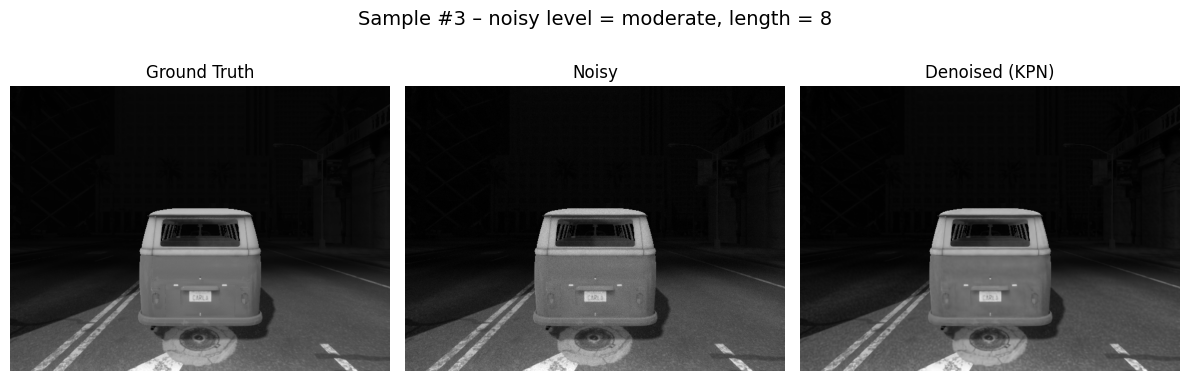

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import numpy as np

def show_triplet(
    gt_path,
    noisy_path,
    denoised_path,
    title="GT / Noisy / Denoised",
    save_path=None,          # 예: "/content/drive/MyDrive/kpn_vis/triplet_01.png"
    figsize=(12, 4)
):
    """
    gt, noisy, denoised 이미지 경로를 받아서
    한 번에 시각화 + (옵션) 저장하는 함수.
    """
    gt_path      = Path(gt_path)
    noisy_path   = Path(noisy_path)
    denoised_path = Path(denoised_path)

    # --- 이미지 로드 (RGB로 통일) ---
    gt_img       = Image.open(gt_path).convert("RGB")
    noisy_img    = Image.open(noisy_path).convert("RGB")
    denoised_img = Image.open(denoised_path).convert("RGB")

    # numpy로 변환
    gt_np       = np.array(gt_img)
    noisy_np    = np.array(noisy_img)
    denoised_np = np.array(denoised_img)

    # --- 시각화 ---
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    axes[0].imshow(gt_np)
    axes[0].set_title("Ground Truth", fontsize=12)
    axes[0].set_xlabel(gt_path.name, fontsize=9)
    axes[0].axis("off")

    axes[1].imshow(noisy_np)
    axes[1].set_title("Noisy", fontsize=12)
    axes[1].set_xlabel(noisy_path.name, fontsize=9)
    axes[1].axis("off")

    axes[2].imshow(denoised_np)
    axes[2].set_title("Denoised (KPN)", fontsize=12)
    axes[2].set_xlabel(denoised_path.name, fontsize=9)
    axes[2].axis("off")

    fig.suptitle(title, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"[OK] triplet saved to: {save_path}")

    plt.show()



#gt = "/content/kpn_repo/dataset/eval_ready/gt/21_gt.bmp"
#noisy = "/content/drive/MyDrive/kpn_custom_noisy2/000_noisy.png"
#denoised = "/content/drive/MyDrive/kpn_denoise_out/denoised_20251116_224712.png"

gt = "/content/drive/MyDrive/kpn_input3/C3_1.bmp"
noisy = "/content/drive/MyDrive/noisy3_moderate/C3_1_noisy.png"
denoised = "/content/drive/MyDrive/denoise3_moderate/pred_win_000.png"

show_triplet(
    gt_path=gt,
    noisy_path=noisy,
    denoised_path=denoised,
    title="Sample #3 – noisy level = moderate, length = 8",
    save_path="/content/drive/MyDrive/new_kpn_vis/triplet_3_moderate.png"
)
